# Frå vegnett til skredmodell i Vestland
Ein praktisk gjennomgang for eiga læring. Køyr cellene ovanfrå og ned.

**Spørsmålet:** Kan tidlegare vêr og veginformasjon hjelpe oss å rangere
strekningar etter om dei får minst eitt **registrert** skred neste kalenderdato?

Løpet er: NVDB-vegnett → skred og kopling → 2 km-buffer → NVE-grid og døgnvêr
→ kvalitet og variablar → tidsdeling → referansemodell og LightGBM
→ kalibrering → sluttest og geografisk kontroll.

Standardkøyringa les eksisterande filer og trenar ein liten demonstrasjonsmodell
i minnet. Ho lastar ikkje ned data eller skriv over første modellrunde.
Demonstrasjonen bruker færre år enn den fullstendige modellen; resultata er derfor
ikkje direkte samanliknbare. Dei fullstendige resultata blir gjennomgått separat.

## Før du byrjar
Vel Python-kjernen frå prosjektet si `.venv` i Jupyter eller VS Code.
Om du manglar Jupyter, køyr desse kommandoane i ein terminal i prosjektmappa:

```powershell
.venv/Scripts/python.exe -m pip install notebook ipykernel
.venv/Scripts/python.exe -m ipykernel install --user --name aktsomhet --display-name "Python (aktsomhet)"
.venv/Scripts/python.exe -m notebook notebooks/skred_ml_laering.ipynb
```

Prosjektpakkane ligg i `requirements.txt`. Jupyter er eit ekstra visingsverktøy.
Filer og versjonar er dokumenterte i [DATA.md](../DATA.md) og [MODEL.md](../MODEL.md).

In [1]:
from pathlib import Path
import os, sys, json, subprocess
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'scripts/tren_modell.py').exists()), None)
assert ROOT is not None, 'Start notebooken frå prosjektmappa eller notebooks/'
os.environ['MPLCONFIGDIR'] = str(ROOT / 'models/.mplcache')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
SEED = 20261004
def read_json(relative):
    return json.loads((ROOT / relative).read_text(encoding='utf-8-sig'))
print('Prosjekt:', ROOT)
print('Python:', sys.executable)

Prosjekt: C:\Users\Aalbu\OneDrive\Dokumenter\Koding\aktsomhet
Python: C:\Users\Aalbu\OneDrive\Dokumenter\Koding\aktsomhet\.venv\Scripts\python.exe


## 1. Hente vegnettet frå NVDB
Uttaket gjeld fylke 46 og eksisterande E-, R- og F-vegar. Skriptet hentar
alle sider frå API-et og bevarer råsvar og SHA256-hashar. Paginering er nødvendig:
den første API-sida er berre ein del av vegnettet.

Vegnummer åleine er ikkje ein unik nøkkel. Me brukar fylke, kategori, fase,
vegnummer og strekning, til dømes `46_EV16_S1`. Delstrekningar og segment
blir samla til strekningar. Desse er administrative NVDB-einingar;
lengdene varierer og er **ikkje faste 10 km**.

Koden under viser førespurnaden, utan å sende han. Produksjonsskriptet er
`scripts/hent_nvdb.py`. Historiske skred blir kopla til dette daterte,
noverande vegnettsuttaket; me har ikkje rekonstruert historiske vegreferansar.

In [2]:
from urllib.parse import urlencode
nvdb_url = 'https://nvdbapiles.atlas.vegvesen.no/vegnett/api/v4/veglenkesekvenser/segmentert'
print(nvdb_url + '?' + urlencode(dict(fylke=46, vegsystemreferanse='EV,RV,FV', antall=1000)))
roads = pd.read_csv(ROOT / 'data/processed/strekningar.csv')
assert roads.strekning_id.is_unique
display(roads.head())
display((roads.lengde_m / 1000).describe().rename('lengde_km'))

https://nvdbapiles.atlas.vegvesen.no/vegnett/api/v4/veglenkesekvenser/segmentert?fylke=46&vegsystemreferanse=EV%2CRV%2CFV&antall=1000


,strekning_id,fylke,vegkategori,fase,vegnummer,strekning,delstrekningar,kommunar,segment_antal,lengde_m,hovudlop_lengde_m,arm_lengde_m,srid,xmin,ymin,xmax,ymax
0,46_EV134_S10,46,E,V,134,10,1,4618,49,9586.307,9586.307,0.000,5973,27092.733,6668709.840,33337.820,6673204.70
1,46_EV134_S11,46,E,V,134,11,1|10,4618,40,20286.003,10427.663,9858.340,5973,33337.820,6660118.620,38245.600,6668709.84
2,46_EV134_S12,46,E,V,134,12,1,4618,61,9391.721,9391.721,0.000,5973,37845.500,6658938.600,44099.430,6661652.66
3,46_EV134_S13,46,E,V,134,13,1|10,4618,30,8781.796,7455.537,1326.259,5973,44099.430,6661180.635,47177.705,6663953.20
4,46_EV134_S14,46,E,V,134,14,1|10,4618,44,16455.645,9754.015,6701.630,5973,47177.705,6659839.770,57425.560,6663107.97


count    957.000000
mean       7.576572
std        4.642674
min        0.003000
25%        4.084462
50%        7.916093
75%       10.029161
max       50.586946
Name: lengde_km, dtype: float64

## 2. Hente skred og lage etikettar
NVDB-objekttype **445** er Skred. Me filtrerer på eigenskap 2324, *Skred dato*,
ikkje datoen då objektet vart oppretta eller sist endra i registeret.
Perioden er 4. oktober 2006–3. oktober 2026.

Eitt skred kan ha fleire referansar til same strekning. Me tel unike skred-ID-ar
per strekning og dato. Eitt skred som treff to strekningar gir to positive
strekning-døgn. Ukopla hendingar blir bevarte for kontroll, ikkje tvinga til
nærmaste veg. Utfallet er `registrert_skred = registrerte_skred > 0`.

Ein null betyr **ingen registrert hending i uttaket**. Registeret dokumenterer
ikkje at ingen skred faktisk skjedde.

In [3]:
slides = pd.read_csv(ROOT / 'data/processed/skred.csv', parse_dates=['dato'])
links = pd.read_csv(ROOT / 'data/processed/skred_strekning.csv')
display(slides[['skred_id', 'dato', 'skredtype', 'match_antal']].head())
display(links.head())
display(slides.skredtype.value_counts().rename('registrerte_hendingar').to_frame())
print('Unike hendingar:', slides.skred_id.nunique())
print('Utan kopling:', int((slides.match_antal == 0).sum()))

Unike hendingar: 16634
Utan kopling: 478


,skred_id,dato,skredtype,match_antal
0,119349648,2006-11-06,Stein,1
1,119349809,2006-10-31,Stein,1
2,119350294,2006-11-06,Flomskred (vann+stein+jord),1
3,119350296,2006-10-31,Stein,1
4,119350298,2006-10-31,Stein,1


,skred_id,dato,skredtype,strekning_id,delstrekning,fra_meter,til_meter,meter,kortform,sideanlegg,kryss
0,119349648,2006-11-06,Stein,46_FV550_S2,1,9813.992,9814.980,NaN,FV550 S2D1 m9814-9815,False,False
1,119349809,2006-10-31,Stein,46_FV5078_S1,1,9526.509,9527.512,NaN,FV5078 S1D1 m9527-9528,False,False
2,119350294,2006-11-06,Flomskred (vann+stein+jord),46_RV7_S20,1,9315.535,9316.542,NaN,RV7 S20D1 m9316-9317,False,False
3,119350296,2006-10-31,Stein,46_FV5078_S1,1,9526.509,9527.512,NaN,FV5078 S1D1 m9527-9528,False,False
4,119350298,2006-10-31,Stein,46_RV13_S26,1,3296.275,3297.605,NaN,RV13 S26D1 m3296-3298,False,False


,registrerte_hendingar
skredtype,
Stein,12140
Is,1169
Jord/løsmasse,1068
Snø,1017
Flomskred (vann+stein+jord),599
Is/stein,318
Sørpeskred (vann+snø+stein),299
Utglidning av veg,16


## 3. Romleg beriking: buffer og gridceller
Me byggjer ein 2 000 meter-buffer rundt dei faktiske veglinjene i EPSG:25833,
eit koordinatsystem med meter som eining. Ein buffer i lengde-/breiddegrader
ville ikkje hatt denne avstanden. Geometrien blir transformert før bufferbygging.

Bufferen blir kryssa med NVE sine 1 km-celler. Bru-tabellen har éi rad per
strekning og celle. `intersection_m2` er arealet av cella inne i bufferen.
Bufferar kan overlappe; kvar celleserie blir likevel henta berre éin gong.
Bufferen kan innehalde fjord og er ikkje eit kartlagt losneområde.

For ein skalar som nedbør brukar me
`middel = sum(areal × celleverdi) / sum(gyldig areal)`.
Me krev minst 80 % gyldig dekning av NVE-støtta landareal den dagen.
Manglande celleverdi er ikkje null nedbør.

In [4]:
bridge = pd.read_parquet(ROOT / 'data/processed/strekning_grid_2km.parquet')
display(bridge.head())
print('Unike celler i bufferane:', bridge.cell_index.nunique())
# Lite rekneeksempel, ikkje faktiske målingar:
area = np.array([100_000., 300_000., 100_000.])
rain = np.array([10., 30., np.nan])
valid = np.isfinite(rain)
coverage = area[valid].sum() / area.sum()
mean = np.average(rain[valid], weights=area[valid]) if coverage >= .8 else np.nan
print(f'Gyldig areal: {coverage:.0%}; vekta nedbør: {mean:.1f} mm')

Unike celler i bufferane: 22807
Gyldig areal: 80%; vekta nedbør: 25.0 mm


,strekning_id,cell_index,intersection_m2,area_weight
0,46_EV134_S10,1582284,112175.858897,0.002278
1,46_EV134_S10,1582285,147961.340460,0.003005
2,46_EV134_S10,1582286,440.703203,0.000009
3,46_EV134_S10,1583477,17426.449883,0.000354
4,46_EV134_S10,1583478,582957.663525,0.011838


## 4. NVE Grid Time Series: døgnvêr
Nedlastinga brukar cellesenter og batchar, med 1 440 minutt tidsoppløysing.
Råsvar, einingar, datoar og førespurnader blir bevarte. Fullførte batchar
kan brukast om att etter avbrot. Skriptet `hent_ver.py` handterer sjølve uttaket.

| Variabel | Tema | Behandla eining |
|---|---|---|
| Nedbør | rr | mm/døgn |
| Nysnødjupn | sdfsw | cm/døgn |
| Temperatur | tm | °C |
| Snødjupn | sd | cm |
| Vindretning | windDirection10m24h06 | grader |
| Vindhastigheit | windSpeed10m24h06 | m/s |
| Modellert jordmetning | gwb_sssrel | % |

Nysnødjupn er ikkje vassekvivalent. Jordmetning er ein modellvariabel,
ikkje målt volumetrisk vassinnhald. Uttaket bruker det menneskelesbare
endepunktet, så me skal ikkje konvertere temperatur frå Kelvin eller snø
frå mm ein gong til. Vind har først gyldige data frå 2013.

In [5]:
# Inspiser ein eksakt, lagra batchførespurnad utan nettverk:
batch_file = next((ROOT / 'data/weather/cells/rr').glob('*.json'))
batch_metadata = json.loads(batch_file.read_text(encoding='utf-8'))
display(batch_metadata['request'])
display(read_json('data/weather/download_report.json'))

{'Theme': 'rr',
 'StartDate': '2006-10-02',
 'EndDate': '2026-10-03',
 'Format': 'json',
 'MapCoordinateCsv': '44500 6664500, 45500 6664500, 46500 6664500, 47500 6664500, 48500 6664500, 49500 6664500, 50500 6664500, -47500 6663500, -46500 6663500, -45500 6663500, -44500 6663500, -43500 6663500, -42500 6663500, -37500 6663500, -36500 6663500, -35500 6663500, -34500 6663500, -33500 6663500, -18500 6663500, -17500 6663500, -16500 6663500, -15500 6663500, -13500 6663500, -12500 6663500, -11500 6663500, -10500 6663500, -9500 6663500, -8500 6663500, -5500 6663500, -4500 6663500, -3500 6663500, -2500 6663500, -500 6663500, 500 6663500, 1500 6663500, 2500 6663500, 3500 6663500, 5500 6663500, 8500 6663500, 9500 6663500'}

{'period': ['2006-10-04', '2026-10-03'],
 'warmup_start': '2006-10-02',
 'unique_cells': 17920,
 'outside_mask_cells': 4887,
 'total_batches': 3136,
 'completed_batches': 3136,
 'failed_batches': [],
 'complete': True,
 'limited_test': False,
 'themes': ['rr',
  'sdfsw',
  'tm',
  'sd',
  'windDirection10m24h06',
  'windSpeed10m24h06',
  'gwb_sssrel'],
 'elapsed_seconds': 734.0,
 'batches': [{'theme': 'rr',
   'request': {'Theme': 'rr',
    'StartDate': '2006-10-02',
    'EndDate': '2026-10-03',
    'Format': 'json',
    'MapCoordinateCsv': '-9500 6935500, -8500 6935500, -7500 6935500, -12500 6934500, -11500 6934500, -10500 6934500, -8500 6934500, -7500 6934500, -12500 6933500, -11500 6933500, -10500 6933500, -9500 6933500, -8500 6933500, -7500 6933500, -12500 6932500, -11500 6932500, -10500 6932500, -9500 6932500, -8500 6932500, -7500 6932500, -6500 6932500, -12500 6931500, -11500 6931500, -10500 6931500, -9500 6931500, -8500 6931500, -7500 6931500, -12500 6930500, -11500 6930500, -10

### Vindretning krev sirkulær statistikk
Vanleg gjennomsnitt av 350° og 10° er 180°, som peikar feil veg.
Me vekter sinus og cosinus, og finn vinkelen med `atan2`.
Resultant nær null betyr at retningane kansellerer kvarandre.

In [6]:
angles = np.deg2rad([350., 10.])
s, c = np.mean(np.sin(angles)), np.mean(np.cos(angles))
direction = np.rad2deg(np.arctan2(s, c)) % 360
if np.isclose(direction, 360): direction = 0.
print('Sirkulært middel:', direction, 'grader; resultant:', np.hypot(s, c))

Sirkulært middel: 0.0 grader; resultant: 0.984807753012208


## 5. Samla tabell og kvalitetskontroll
Sluttdatasettet har éi rad per strekning og døgn, fordelt på årlege Parquet-filer.
Me kontrollerer unike nøklar, komplett kalender, bevarte skredteljingar,
arealvekting, laggar og einingar. `valider_datasett.py` kontrollerer også mot
dei underliggjande celleseriane; berre å sjå på tabellen er ikkje tilstrekkeleg.

Nokre originale jordmetningsverdiar var utanfor 0–100 %. Vår dokumenterte
kontrollregel set dei til manglande i behandla data og bevarer originalane.
Ein strekning manglar støtta vêrceller og er framleis med i panelet.

In [7]:
sample = pd.read_parquet(ROOT / 'data/weather/strekning_dogn/2025.parquet')
assert not sample.duplicated(['strekning_id', 'dato']).any()
assert sample.groupby('dato').size().eq(len(roads)).all()
assert sample.registrert_skred.eq(sample.registrerte_skred.gt(0).astype(int)).all()
display(sample[['strekning_id', 'dato', 'nedbor_mm_lag1',
                'nedbor_mm_sum3d_lag1', 'registrerte_skred']].head())
display(sample[['nedbor_mm_lag1', 'vindhastigheit_ms_lag1',
                'jord_vassmetning_pct_lag1']].isna().mean().rename('manglande_andel'))
display(read_json('data/weather/validation_report.json'))

,strekning_id,dato,nedbor_mm_lag1,nedbor_mm_sum3d_lag1,registrerte_skred
0,46_EV134_S10,2025-01-01,0.617215,85.898178,0
1,46_EV134_S11,2025-01-01,1.977327,66.939621,0
2,46_EV134_S12,2025-01-01,1.705351,44.113640,0
3,46_EV134_S13,2025-01-01,1.209053,38.504265,0
4,46_EV134_S14,2025-01-01,1.174295,26.150581,0


nedbor_mm_lag1               0.001045
vindhastigheit_ms_lag1       0.001045
jord_vassmetning_pct_lag1    0.053449
Name: manglande_andel, dtype: float64

{'validated': True,
 'section_days': 6990885,
 'event_section_links': 16262,
 'checks': ['unique keys and full daily calendar',
  'event counts preserved',
  'manual source-cell area-weighted precipitation and maximum',
  '3-day sum and preceding-day lag alignment',
  'manual source-cell circular mean',
  'circular angle wrap-around',
  'processed soil saturation range 0-100 percent']}

## 6. Variablar og datalekkasje
For måldato *t* brukar me berre tidlegare vêr. `lag1` er dato *t−1*;
`sum3d_lag1` er summen av *t−3*, *t−2* og *t−1*. Same-dagsvêr kan innehalde
vêr etter skredet. `sum3d` utan lag må derfor ikkje forvekslast med modellvariabelen.

Lagging må gjerast **innan kvar strekning**, etter sortering på dato.
Me les desember frå førre år for å få historikk ved nyttår. Eksemplet under
kontrollerer dei eksisterande tre-døgnssummane for éi strekning.

In [8]:
SID = '46_EV134_S10'
one = pd.concat([pd.read_parquet(ROOT / f'data/weather/strekning_dogn/{yr}.parquet',
                  filters=[('strekning_id', '==', SID)]) for yr in [2024, 2025]], ignore_index=True)
one = one.sort_values('dato').reset_index(drop=True)
one['rekna_sum3d_lag1'] = one.nedbor_mm_mean.shift(1).rolling(3, min_periods=3).sum()
check = one.dato.between('2025-01-01', '2025-12-31')
np.testing.assert_allclose(one.loc[check, 'rekna_sum3d_lag1'],
                           one.loc[check, 'nedbor_mm_sum3d_lag1'],
                           rtol=1e-5, atol=1e-5, equal_nan=True)
display(one.loc[check, ['dato', 'nedbor_mm_mean', 'nedbor_mm_lag1',
                        'nedbor_mm_sum3d_lag1', 'registrert_skred']].head(8))

,dato,nedbor_mm_mean,nedbor_mm_lag1,nedbor_mm_sum3d_lag1,registrert_skred
366,2025-01-01,42.639126,0.617215,85.898178,0
367,2025-01-02,0.230550,42.639126,87.119934,0
368,2025-01-03,10.865138,0.230550,43.486893,0
369,2025-01-04,0.029939,10.865138,53.734814,0
370,2025-01-05,0.169931,0.029939,11.125627,0
371,2025-01-06,4.880623,0.169931,11.065007,0
372,2025-01-07,10.474308,4.880623,5.080492,0
373,2025-01-08,0.060163,10.474308,15.524862,0


Årstid og vind blir representerte med sinus/cosinus, slik at desember/januar
og 359°/1° ligg nær kvarandre. Den fullstendige modellen har 22 vêr-/sesongvariablar
og 4 vegvariablar. Skredteljingar frå heile perioden skal aldri brukast som
historisk prediktor: då ville framtidige hendingar lekke inn.

GTS sine kalenderetikettar er ikkje dokumentert som identiske meteorologiske
døgn eller tilgjengelege på same klokkeslett. Kalenderlagging er kontrollert,
men operativ tilgjengelegheit må avklarast før faktisk varsling.

## 7. Tidsdeling før trening
Tilfeldig radfordeling ville blande framtida inn i trening og leggje
nabostrekningar frå same vêrdøgn på begge sider. Første fulle modellrunde bruker:

| Del | År | Føremål |
|---|---|---|
| Trening | 2013–2020 | Tilpasse modell og historisk referanse |
| Validering | 2021–2022 | Tidleg stopp og modellval |
| Kalibrering | 2023 | Tilpasse sannsynsskala |
| Sluttest | 2024–3. oktober 2026 | Endeleg evaluering |

2012 gir oppvarming for laggar. Sluttesten er no undersøkt og må ikkje
brukast om att som ein urørt test etter mykje tuning mot resultata.

In [9]:
audit = read_json('models/first_run/data_audit.json')
display(pd.DataFrame(audit['splits']).T)
display(pd.Series(audit['weather_features'], name='fullstendige_vêrvariablar'))

,rows,positives,start,end
train,2796354,5221,2013-01-01,2020-12-31
validation,698610,1736,2021-01-01,2022-12-31
calibration,349305,916,2023-01-01,2023-12-31
test,963699,2501,2024-01-01,2026-10-03


0                                    nedbor_mm_lag1
1                                nysnodjupn_cm_lag1
2                                 temperatur_c_lag1
3                                  snodjupn_cm_lag1
4                            vindhastigheit_ms_lag1
5                         jord_vassmetning_pct_lag1
6                              nedbor_mm_sum3d_lag1
7                          nysnodjupn_cm_sum3d_lag1
8                nedbor_mm_valid_fraction_land_lag1
9     jord_vassmetning_pct_valid_fraction_land_lag1
10       vindhastigheit_ms_valid_fraction_land_lag1
11                vindretning_grader_resultant_lag1
12                               nedbor_mm_max_lag1
13                           nysnodjupn_cm_max_lag1
14                             nedbor_mm_sum7d_lag1
15                         nysnodjupn_cm_sum7d_lag1
16                          temperatur_endring_lag1
17                            snodjupn_endring_lag1
18                             vindretning_sin_lag1
19          

## 8. Ei mindre trening du kan eksperimentere med
No trenar du ein **eigen demonstrasjon i minnet**, med 2019–2020 til trening,
2021 til validering, 2022 til kalibrering og 2023 til test. Alle strekningar
er med, og klassefordelinga blir bevart. Me brukar eit lite utval variablar
og opptil 100 tre for at dette skal vere lettare å prøve.

Historisk referanse blir tilpassa berre treningsdata. LightGBM kan lære
ikkje-lineære samanhengar og samspel, og handterer manglande verdiar direkte.
Me deler ikkje desse resultata som ei ny full modellrunde.

In [10]:
sys.path.insert(0, str(ROOT / 'scripts')) if str(ROOT / 'scripts') not in sys.path else None
import tren_modell as pipeline
import lightgbm as lgb
from sklearn.metrics import average_precision_score, brier_score_loss
features = ['nedbor_mm_lag1', 'nedbor_mm_sum3d_lag1',
            'nysnodjupn_cm_sum3d_lag1', 'temperatur_c_lag1',
            'snodjupn_cm_lag1', 'vindhastigheit_ms_lag1', 'jord_vassmetning_pct_lag1']
columns = ['strekning_id', 'dato', 'registrert_skred'] + features
demo = pd.concat([pd.read_parquet(ROOT / f'data/weather/strekning_dogn/{yr}.parquet',
                                columns=columns) for yr in range(2019, 2024)], ignore_index=True)
demo = demo.sort_values(['dato', 'strekning_id']).reset_index(drop=True)
keys = demo[['strekning_id', 'dato']].copy()
keys['month'] = keys.dato.dt.month
y = demo.registrert_skred.to_numpy()
X = demo[features].copy()
doy = demo.dato.dt.dayofyear
X['arstid_sin'] = np.sin(2*np.pi*doy/365.25)
X['arstid_cos'] = np.cos(2*np.pi*doy/365.25)
train = demo.dato.dt.year.le(2020).to_numpy()
val = demo.dato.dt.year.eq(2021).to_numpy()
cal = demo.dato.dt.year.eq(2022).to_numpy()
test = demo.dato.dt.year.eq(2023).to_numpy()
assert np.all(train.astype(int) + val + cal + test == 1)
display(pd.DataFrame([{'del': name, 'rader': int(m.sum()), 'positive': int(y[m].sum())}
                     for name, m in [('trening', train), ('validering', val),
                                     ('kalibrering', cal), ('test', test)]]))
history = pipeline.history_fit(keys, y, train)
model = lgb.LGBMClassifier(**{**pipeline.PARAMS, 'n_estimators': 100, 'n_jobs': 4})
model.fit(X.loc[train], y[train], eval_set=[(X.loc[val], y[val])],
          callbacks=[lgb.early_stopping(20, verbose=False)])
print('Valt tal tre:', model.best_iteration_)

Valt tal tre: 27


C:\Users\Aalbu\OneDrive\Dokumenter\Koding\aktsomhet\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,del,rader,positive
0,trening,699567,1334
1,validering,349305,762
2,kalibrering,349305,974
3,test,349305,916


## 9. Kalibrering og evaluering av demonstrasjonen
Ei rangering kan vere nyttig utan at skårane er gode sannsyn.
Sigmoidkalibrering tilpassar skalaen på eit separat år. Ho skal ikkje
tilpassast på testdata. Kalibreringsåret er ikkje ein uavhengig test.

Me samanliknar average precision (AP), Brier og topp 10 per dag.
Recall ved topp 10 er delen av positive strekning-døgn som blir fanga.
Precision ved topp 10 er delen av flagga som har registrert skred.
Ved sjeldne hendingar kan ein modell få over 99 % accuracy ved å seie
«ingen skred» kvar dag; accuracy er derfor eit dårleg hovudmål her.

In [11]:
raw_cal = model.predict_proba(X.loc[cal])[:, 1]
calibration = pipeline.calibrated(raw_cal, y[cal])
raw_test = model.predict_proba(X.loc[test])[:, 1]
demo_score = pipeline.apply_cal(raw_test, calibration)
history_cal = pipeline.calibrated(pipeline.history_predict(history, keys.loc[cal]), y[cal])
history_score = pipeline.apply_cal(pipeline.history_predict(history, keys.loc[test]), history_cal)
def summary(score, name):
    ranked = keys.loc[test, ['strekning_id', 'dato']].copy()
    ranked['y'], ranked['score'] = y[test], score
    # Same seeded tie order for both models; avoid alphabetical preference.
    ids = sorted(ranked.strekning_id.unique())
    tie = dict(zip(ids, np.random.default_rng(SEED).permutation(len(ids))))
    ranked['tie'] = ranked.strekning_id.map(tie)
    top = ranked.sort_values(['dato', 'score', 'tie'], ascending=[True, False, True]).groupby('dato').head(10)
    return dict(modell=name, AP=average_precision_score(y[test], score),
                Brier=brier_score_loss(y[test], score),
                recall_topp10=top.y.sum()/y[test].sum(), precision_topp10=top.y.mean())
demo_metrics = pd.DataFrame([summary(history_score, 'Historisk referanse'),
                             summary(demo_score, 'Liten vêrmodell')])
display(demo_metrics)
print('Grunnfrekvens i demonstrasjonstesten:', y[test].mean())

Grunnfrekvens i demonstrasjonstesten: 0.002622350095189018


,modell,AP,Brier,recall_topp10,precision_topp10
0,Historisk referanse,0.008389,0.002611,0.062227,0.015616
1,Liten vêrmodell,0.004037,0.002615,0.013100,0.003288


## 10. Dei lagra resultata frå den fullstendige modellen
Dette er den faktiske første modellrunden med tidsdelinga frå kapittel 7,
ikkje demonstrasjonen. Vêr og veg vart valt på valideringsdata.
Sluttesten viser ingen dokumentert gevinst ved ti daglege flagg:
174 positive døgn mot referansen sine 176, av 2 501 positive døgn totalt.
Betre AP treng ikkje bety betre topp 10; måla vurderer ulike delar av rangeringa.

,model,average_precision,true_positive_top10,recall_top10,precision_top10,brier
2,historical_frequency,0.009749,176,0.070372,0.017478,0.002580
5,weather,0.011604,162,0.064774,0.016087,0.002578
8,weather_and_road,0.012481,174,0.069572,0.017279,0.002580


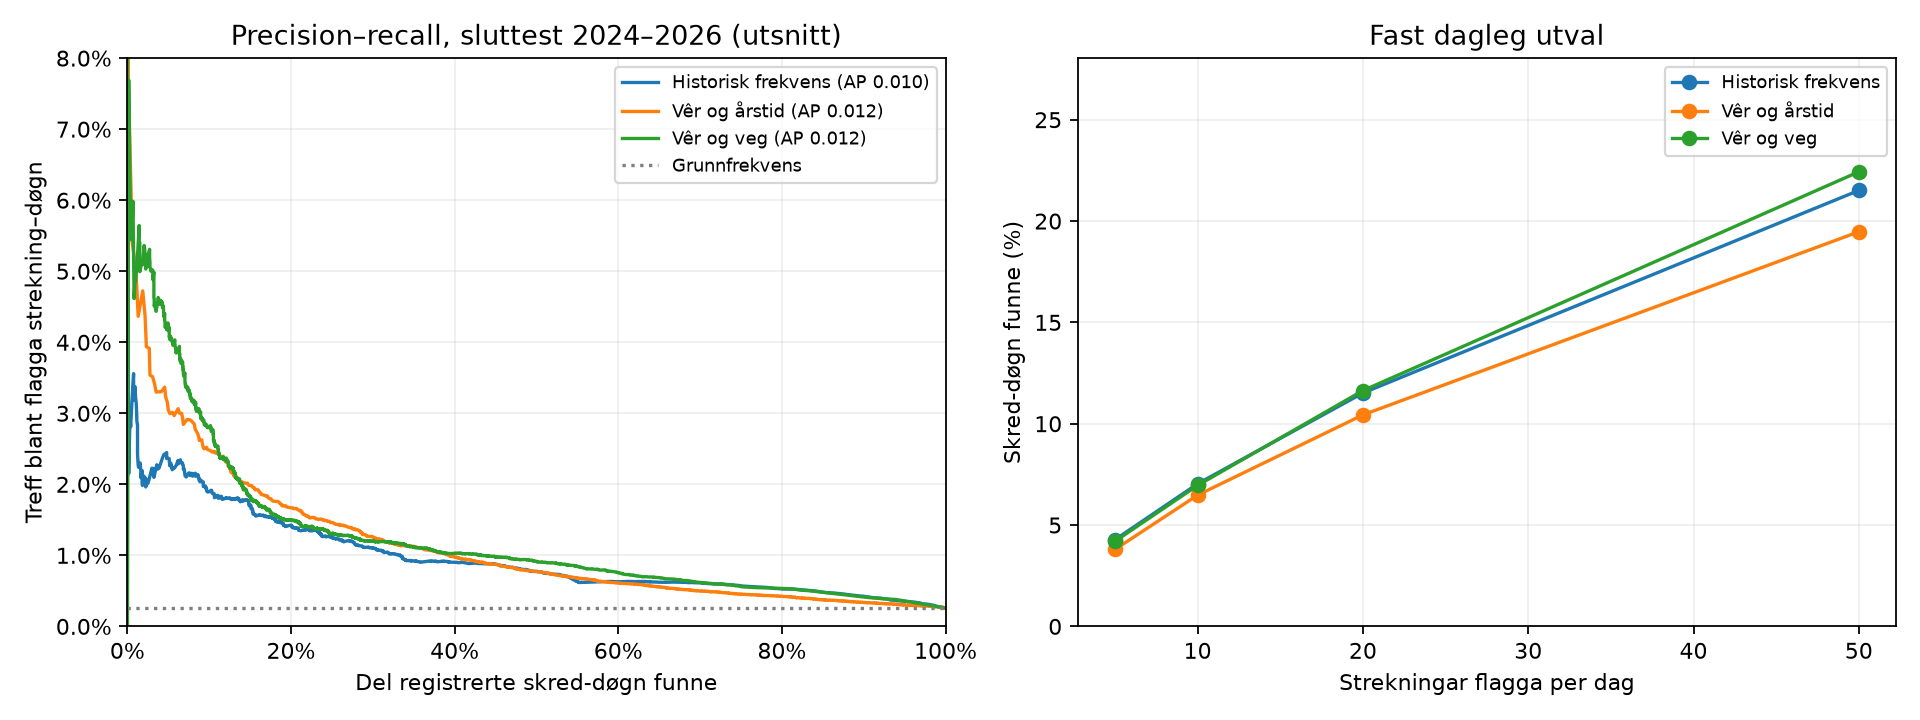

In [12]:
metrics = pd.read_csv(ROOT / 'models/first_run/temporal/metrics.csv')
display(metrics.loc[metrics['split'].eq('test'),
                    ['model', 'average_precision', 'true_positive_top10',
                     'recall_top10', 'precision_top10', 'brier']])
from IPython.display import Image
display(Image(filename=str(ROOT / 'models/first_run/temporal/evaluation.png')))

### Sjå på prediksjonane for ein dato
Topp 10 er eit fast dagleg budsjett, ikkje ein sannsynsterskel. Det vil flagge
ti strekningar også på dagar med låg skår. Vel ein annan dato for å utforske.

In [13]:
DATE = '2025-01-01'
pred = pd.read_parquet(ROOT / 'models/first_run/temporal/weather_and_road_test_predictions.parquet')
display(pred.loc[pred.dato.eq(pd.Timestamp(DATE))].sort_values('score', ascending=False).head(10))
importance = pd.read_csv(ROOT / 'models/first_run/temporal/weather_and_road_importance.csv')
display(importance.head(10))

,strekning_id,dato,target,raw_score,score
351077,46_FV609_S5,2025-01-01,0,0.012978,0.015425
350270,46_EV134_S7,2025-01-01,0,0.008448,0.010369
350839,46_FV5623_S1,2025-01-01,0,0.008109,0.009983
350856,46_FV5637_S1,2025-01-01,0,0.007861,0.009701
350813,46_FV5600_S2,2025-01-01,0,0.007841,0.009678
351027,46_FV57_S17,2025-01-01,0,0.007462,0.009245
350810,46_FV55_S8,2025-01-01,0,0.007300,0.009058
350915,46_FV5685_S1,2025-01-01,0,0.007146,0.008881
351150,46_RV13_S27,2025-01-01,0,0.007131,0.008864
350638,46_FV53_S6,2025-01-01,0,0.007101,0.008830


,feature,gain,splits
0,strekning_kode,49750.916325,81
1,vindhastigheit_ms_lag1,1301.246485,11
2,lengde_km,1042.031788,8
3,arstid_sin,1000.701914,17
4,temperatur_c_lag1,949.160900,18
5,nysnodjupn_cm_sum7d_lag1,924.727602,9
6,arstid_cos,861.087812,13
7,nysnodjupn_cm_sum3d_lag1,573.866106,12
8,nedbor_mm_max_lag1,492.477810,7
9,snodjupn_endring_lag1,469.972200,8


Gain-fordelinga viser at strekningsidentiteten dominerer den første kombinerte
modellen. Gain er ikkje eit kausalt mål og kan favoriserast av kategoriske
variablar. Det viser kva modellen brukar i splittingane, ikkje at vegnummer
eller ei bestemt vêrvariabel i seg sjølv forårsakar skred.

## 11. Usikkerheit og geografisk kontroll
Nabodagar deler vêr og skredhendingar. Vanleg bootstrap av enkelt­rader ville
behandle desse som uavhengige. Me trekkjer kalender-månadsblokker, med same
blokker for begge modellar, og samanliknar recall. Første runde brukte 1 000
trekningar. Intervallet for endringa mot historisk referanse er −0,92 til
+0,69 prosentpoeng: det støttar ikkje ein sikker gevinst.

Dette intervallet gjeld faste, ferdigtrena modellar; det dekkjer ikkje
usikkerheit frå ny trening eller manglande skredregistreringar.

Geografisk kontroll held 89 nordlege strekningar utanfor trening,
validering og kalibrering, og testar framtidige datoar i det nye området.
Ein 4 km avstand mellom strekningsboksane skil 2 km-bufferane.
Grensene vart valde frå koordinatar, utan å bruke skredetikettar.

In [14]:
display(read_json('models/first_run/temporal/bootstrap.json'))
geo = read_json('models/first_run/geographic/geography.json')
print('Haldne utanfor:', len(geo['held_section_ids']))
print('Treningsområdet:', len(geo['training_section_ids']))
gm = pd.read_csv(ROOT / 'models/first_run/geographic/metrics.csv')
display(gm.loc[gm['split'].eq('test'), ['model', 'positives', 'true_positive_top10', 'recall_top10']])
display(read_json('models/first_run/validation_report.json'))

Haldne utanfor: 89
Treningsområdet: 849


{'block': 'calendar month',
 'replicates': 1000,
 'results': {'historical_frequency': {'recall_top10_ci95': [0.060052644581640946,
    0.08131850973071521]},
  'weather': {'recall_top10_ci95': [0.05642558179644946, 0.07422380952380951],
   'difference_vs_history_ci95': [-0.015622685421569141, 0.00493035621750345]},
  'weather_and_road': {'recall_top10_ci95': [0.059750036818358304,
    0.07921802240385555],
   'difference_vs_history_ci95': [-0.00917531844992781, 0.0068906202702547]}},
 'limitation': 'Conditional on fitted models; not uncertainty from refitting or registration bias'}

,model,positives,true_positive_top10,recall_top10
2,historical_frequency,257,23,0.089494
5,weather_and_road,257,48,0.186770


{'validated': True,
 'checked': ['temporal/historical_frequency',
  'temporal/weather',
  'temporal/weather_and_road',
  'geographic/historical_frequency',
  'geographic/weather_and_road'],
 'checks': ['source file hashes',
  'lag and 7-day window alignment',
  'test keys and labels',
  'top-10 counts',
  'metrics from saved predictions',
  'reloaded model and calibration reproduce predictions',
  'geographic separation',
  'selection uses validation only']}

Den geografiske kontrollen gav eit positivt resultat for vêr og veg, men berre
i eitt område. Topp 10 av 89 strekningar er eit langt større utval enn topp 10
av 957. Desse recall-tala kan derfor ikkje samanliknast direkte.

## 12. Køyre heile produksjonsløpet på nytt
Desse cellene er **av som standard**. Dei viser eksakt rekkjefølgje og brukar
den same Python-kjernen som notebooken. Nedlastinga kan vere stor og skriv i
eksisterande datamapper. Modellskriptet skriv over `models/first_run`.
Ta kopi av data/resultat før eit nytt uttak eller eksperiment.
Datoane ligg i skripta og må endrast samordna ved ein ny periode.

In [15]:
RUN_DOWNLOAD = False
RUN_TRAINING = False
RUN_VALIDATION = False
def run_script(name):
    subprocess.run([sys.executable, str(ROOT / 'scripts' / name)], cwd=ROOT, check=True)
if RUN_DOWNLOAD:
    for script in ['hent_nvdb.py', 'hent_skred.py', 'lag_buffer.py',
                   'hent_nve_metadata.py', 'kontroller_gridmaske.py',
                   'hent_ver.py', 'aggreger_ver.py', 'valider_datasett.py']:
        run_script(script)
if RUN_TRAINING:
    run_script('tren_modell.py')
if RUN_VALIDATION:
    run_script('valider_datasett.py')
    run_script('valider_modell.py')
print('Produksjonsløpet køyrer berre når du set eit av vala til True.')

Produksjonsløpet køyrer berre når du set eit av vala til True.


## 13. Aktsomheitsområde som romleg beriking
NVE-zipfila som vart lagt inn i prosjektet inneheld aktsomheitskart for
steinsprang, jord-/flaumskred og fleire snøskredvariantar. Skriptet
`kople_aktsomhet.py` les GeoJSON direkte frå zip, med strøymande JSON-lesing.
Filer i dette uttaket har eksplisitt EPSG:25833, ikkje lengde-/breiddegrader.

Me brukar det samla jord-/flaumlaget, både losne- og utløpsområde for steinsprang,
og snøskred S2 utan skogeffekt. S2/S3 er namn på kartvariantar frå arealplanlegging;
dei er ikkje klassar for risiko langs veg. Andre snøvariantar ligg framleis i råfila.

Overlappen blir rekna mot veglinjene, ikkje vêrbufferen. Overlappande polygon
blir ikkje dobbelttelte: me tek lokal union av polygon før veglinja blir
kryssa med dei. Nemnaren er geometrisk union-lengd, som kan avvike frå summert
NVDB-lengd. Ein eigen 20 m-regel er berre ein sensitivitetskontroll.

Originaldata er bevarte. `behald_direkte` er eit mogleg filter, medan meter
og andel innanfor kvart tema er moglege nye modellvariablar. Kontrollrapporten
viser kor mange registrerte skred filteret ville ha utelate. Dette er ikkje
ei ny modelltrening, og betre prediksjonsevne er ikkje demonstrert.

Karta er eit noverande uttak frå 2026 og kan byggje på seinare kunnskap enn
historiske måldatoar. Ingen overlapp er ikkje dokumentasjon på null skredfare.
Eit skred på ein behalden strekning er heller ikkje nødvendigvis inne i eit
polygon; kontrollen her er på strekningsnivå.

In [16]:
hazard_file = ROOT / 'data/processed/aktsomhet/strekning_aktsomhet.parquet'
if hazard_file.exists():
    hazard = pd.read_parquet(hazard_file)
    enriched_roads = roads.merge(hazard, on='strekning_id', validate='one_to_one')
    assert len(enriched_roads) == len(roads)
    display(enriched_roads[['strekning_id', 'stein_andel', 'jord_flaum_andel',
                            'sno_s2_utan_skog_andel', 'behald_direkte']].head())
    display(pd.DataFrame(read_json('data/processed/aktsomhet/rapport.json')['summaries']))
    display(pd.read_csv(ROOT / 'data/processed/aktsomhet/skredtype_filterkontroll.csv'))
else:
    print('Køyr scripts/kople_aktsomhet.py først for å lage denne berikinga.')

,strekning_id,stein_andel,jord_flaum_andel,sno_s2_utan_skog_andel,behald_direkte
0,46_EV134_S10,0.341671,0.411778,0.177580,True
1,46_EV134_S11,0.485849,0.331658,0.010528,True
2,46_EV134_S12,0.556211,0.165741,0.000000,True
3,46_EV134_S13,0.295937,0.405848,0.006922,True
4,46_EV134_S14,0.457774,0.313660,0.161814,True


,period,rule,sections_retained,sections_removed,unique_events_on_removed_sections,events_only_on_removed_sections,event_section_links_removed,positive_section_days_removed,positive_section_days_total
0,alle_20aar,behald_direkte,837,120,105,104,105,94,13595
1,alle_20aar,behald_innan20m,869,88,40,39,40,37,13595
2,trening_2013_2020,behald_direkte,837,120,35,34,35,31,5221
3,trening_2013_2020,behald_innan20m,869,88,12,11,12,11,5221
4,sluttest_2024_2026,behald_direkte,837,120,25,25,25,22,2501
5,sluttest_2024_2026,behald_innan20m,869,88,11,11,11,10,2501


,skredtype,behald_direkte,unike_hendingar,hending_strekning_koplingar
0,Flomskred (vann+stein+jord),False,1,1
1,Flomskred (vann+stein+jord),True,579,585
2,Is,True,1145,1150
3,Is/stein,True,302,304
4,Jord/løsmasse,False,6,6
5,Jord/løsmasse,True,1037,1049
6,Snø,True,971,979
7,Stein,False,98,98
8,Stein,True,11701,11769
9,Sørpeskred (vann+snø+stein),True,293,297


## 14. Historiske vegmeldingar: eit alternativt utfall
Me har lasta ned heile det tilgjengelege nasjonale laget `XgeoVeimelding2/13`
for meldingsdatoar til og med 3. oktober 2026: 105 407 postar. Årsvis
paginering, hashkontroll og teljing før/etter kvar årsfil gjer uttaket
etterprøvbart. Ingen meldingar vart funne i 2006–2009 i dette laget.

`filtrer_xgeo_vegmeldingar.py` finn geografiske kandidatar og skil tekst som
omtalar skred/nedfall frå rasfare, kontrollert utløsning, opning etter skred
og andre forhold. Skredtypane blir ikkje brukte som separate ML-etikettar.
Isnedfall er med i dette breie utfallet, slik det også er i NVDB-utfallet.

Det strenge kandidatutfallet krev same vegkategori og anten dagens nummer
eller eit dokumentert gammalt nummer i Vegvesenet sine reformlister.
Gamle fylke blir bestemt frå kommunen på den aktuelle veggeometrien.
For nummeromsetjinga tillèt me gamle alias til og med 2021; bruk etter
NVDB si endringsdato blir særskilt markert. Dette er ei overgangsregel,
ikkje eit eksakt oppslag av referansens gyldigheit på meldingsdatoen.
Meldingane manglar hovudparsell/meter, så koordinat skil mellom greinene
når ein gammal veg vart delt i fleire nye nummer.

Utvalet krev vidare eit eintydig
visingspunkt innan 100 m frå dagens veglinje, minst 20 m avstandsskilnad
til nest næraste strekning, og at eventuelle start-/sluttpunkt ikkje ligg
meir enn 100 m frå den valde strekninga. Dette er forsøksreglar, ikkje
verifisert stadnøyaktigheit. Kategoriendringar, vegomleggingar og eldre
omnummereringar utanfor reformlistene kan framleis gi manglande kopling.

Etter rettinga aukar positive strekning–døgn i 2013–2020 frå 311 til 599.
Eit positivt døgn er ein strekning/dato med minst éin behalden episode,
uavhengig av kor mange oppdateringar eller skred som er registrerte den dagen.

Oppdateringar med same situasjon og strekning blir samla i episodekandidatar.
Me deler ved eit opphald over sju døgn. Dette kan både slå saman to ulike
skred og dele ei langvarig hending; det må kontrollerast. Etikettdatoen er
den første positive meldingas gyldigheitsstart, ikkje stadfesta skredtid.

Dagstabellane tilbyr NVDB, Xgeo og unionen som tre utfall, utan å endre
originaldata. Null betyr ingen behalden melding, ikkje dokumentert skredfråvær.
Ein union av binære døgnetikettar gir berre éin positiv per strekning/dato;
det er ikkje det same som deduplisering av hendingar mellom kjeldene.

In [17]:
message_root = ROOT / 'data/processed/vegmeldingar'
if (message_root / 'filterrapport.json').exists():
    display(read_json('data/processed/vegmeldingar/filterrapport.json'))
    display(pd.read_csv(message_root / 'kjeldesamanlikning_per_ar.csv'))
    display(pd.read_csv(message_root / 'filtersteg_per_ar.csv'))
    if (message_root / 'historisk_kopling_per_ar.csv').exists():
        display(pd.read_csv(message_root / 'historisk_kopling_per_ar.csv'))
    # Kopling av alternative etikettar til det eksisterande vêrgrunnlaget:
    labels_2025 = pd.read_parquet(message_root / 'etikettar_dogn/2025.parquet')
    learning_2025 = sample.merge(
        labels_2025.drop(columns='registrert_skred'),
        on=['strekning_id','dato'], validate='one_to_one')
    assert len(learning_2025) == len(sample)
    display(learning_2025.loc[learning_2025.vegmelding_skred.eq(1),
        ['strekning_id','dato','registrert_skred','vegmelding_skred',
         'skred_ei_av_kjeldene','nedbor_mm_sum3d_lag1']].head())
else:
    print('Hent og filtrer vegmeldingane først; sjå VEGMELDINGAR_UTTAK.md.')

{'national_rows': 105407,
 'study_candidate_rows': 23177,
 'name_candidate_rows': 13728,
 'spatial_candidate_rows': 22023,
 'classes': {'anna': 12523,
  'meldt_skred': 8948,
  'skredfare': 1487,
  'opning_etter_skred': 200,
  'kontrollert_skred': 17,
  'uavklart': 2},
 'matched_rows': 19077,
 'coarse_matched_rows': 1802,
 'strict_message_rows': 7191,
 'episode_candidates': 5291,
 'strict_episode_candidates': 4787,
 'strict_positive_section_days': 4522,
 'same_day_both': 1134,
 'xgeo_only_positive_days': 3388,
 'nvdb_only_positive_days': 9240,
 'rules': {'max_distance_m': 100,
  'ambiguity_margin_m': 20,
  'episode_gap_days': 7,
  'period': ['2013-01-01', '2026-10-03']},
 'warnings': ['Rule-based labels and episodes are unverified candidates; manual review required before model replacement',
  'Same-day overlap is not a verified match between individual events',
  'Missing message means no retained report, not absence of slides or verified monitoring coverage',
  'Official reform aliase

,year,nvdb_positive_dogn,vegmelding_positive_dogn,union_positive_dogn,same_dato_strekning_begge
0,2013,587,75,631,31
1,2014,488,49,515,22
2,2015,651,95,708,38
3,2016,522,86,575,33
4,2017,673,69,715,27
5,2018,966,101,1030,37
6,2019,711,61,750,22
7,2020,623,63,656,30
8,2021,762,158,878,42
9,2022,974,544,1371,147


,year,candidate_rows,explicit_slide_rows,matched_explicit_slide_rows,coarse_explicit_slide_rows,strict_message_rows
0,2010,1,1,1,0,0
1,2011,418,284,209,3,0
2,2012,455,216,109,6,0
3,2013,571,243,172,1,171
4,2014,727,145,111,0,111
5,2015,1024,370,204,4,200
6,2016,560,259,186,3,183
7,2017,530,189,163,10,153
8,2018,761,333,222,5,217
9,2019,558,175,119,0,119


,year,before_positive_days,after_positive_days,added_positive_days,removed_positive_days,net_change
0,2013,41,75,34,0,34
1,2014,24,49,25,0,25
2,2015,40,95,55,0,55
3,2016,42,86,44,0,44
4,2017,31,69,38,0,38
5,2018,40,101,61,0,61
6,2019,31,61,30,0,30
7,2020,62,63,1,0,1
8,2021,158,158,0,0,0
9,2022,544,544,0,0,0


,strekning_id,dato,registrert_skred,vegmelding_skred,skred_ei_av_kjeldene,nedbor_mm_sum3d_lag1
1079,46_FV49_S9,2025-01-02,0,1,1,36.658924
1843,46_RV13_S25,2025-01-02,0,1,1,89.364616
1910,46_RV7_S22,2025-01-02,0,1,1,28.114195
3471,46_FV563_S2,2025-01-04,1,1,1,17.608084
5694,46_RV13_S48,2025-01-06,0,1,1,0.151051


Utforsk `manuell_kontroll.csv`: kan du finne feil i teksten eller koplinga?
Utvalet er stratifisert på år, klasse og om meldinga oppfyller dei strenge
radreglane. Fyll inn `review_label` og `review_comment` i ei kopi.
Mål presisjon og kva faktiske skred som blir mista før du skiftar modellutfall.

Den første modellen vår brukte allereie alle NVDB-skredtypar samla.
Eitt samla utfall unngår usikker typeklassifisering, men blandar prosessar
som reagerer ulikt på vêr. Det garanterer ikkje betre prediksjonar.
Omnummerering forklarte ein del av det låge utvalet før 2021 og er no retta
med reformlistene og geografisk kontroll. Det er framleis færre eldre
melding­ar i kjelda, og eit lågare behalde utval må vurderast;
ein modell kan elles lære endra registreringspraksis.

## 15. Oppgåver for vidare læring
1. Byt `SID` og samanlikn vêr og registrerte skred på to strekningar.
2. Fjern nysnø frå demonstrasjonsmodellen. Endrar valideringsresultatet seg?
3. Rekn topp 5 og topp 50. Korleis endrar recall og precision seg?
4. Undersøk manglande jordmetning og kvifor nullutfylling ville gi feil meining.
5. Planlegg separate modellar for snøskred, steinsprang og jord-/flomskred.
   Definer nye etikettar og tidsvalidering før du ser på nye testresultat.
6. Planlegg terrengvariablar: helling, høgd og terrenget over vegane, og
   handtering av tunnelar og skredsikring. Ein 2 km-buffer er berre eit første grep.

Ved gjenteken eksperimentering blir teståret i demonstrasjonen utviklingsdata.
Bruk rullande tidsvalidering for modellval og reserver ein ny, definert sluttest.

### Kjelder og kode
- [NVDB API Les V4](https://nvdb-docs.atlas.vegvesen.no/nvdbapil/v4/Vegnett/)
- [NVE Grid Time Series](https://api.nve.no/doc/gridtimeseries-data-gts/)
- [LightGBM](https://lightgbm.readthedocs.io/en/stable/Python-API.html)
- [scikit-learn: average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)
- [Datadokumentasjon](../DATA.md), [modellrapport](../MODEL.md),
  [treningskode](../scripts/tren_modell.py), [uavhengig modellkontroll](../scripts/valider_modell.py).

Krediter NVDB/Statens vegvesen og NVE med underliggjande dataleverandørar ved vidare bruk.